In [51]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [ ]:
from proj2dhullsampler import HistoryMatching

In [53]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "test"

para = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc")
para = para.to_dataframe().drop(columns = 'Sample_nmb')
para.index = para.index +1




In [54]:
test_case = HistoryMatching(working_dir, case_name, para)
test_case.drop_by_name(["TGCLDLWP", "CLDTOT"])
test_case.drop_by_n_survive(n_survive = 200000)
test_case.update_meta()



In [55]:
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

micro_mg_vtrmi_factor                    and micro_mg_dcs                            :        0
micro_mg_dcs                             and microp_aero_wsub_scale                  :   303132
micro_mg_dcs                             and microp_aero_wsubi_scale                 :   644264
microp_aero_wsub_scale                   and microp_aero_npccn_scale                 :   779749
micro_mg_vtrmi_factor                    and microp_aero_wsub_scale                  :   974270
micro_mg_vtrmi_factor                    and zmconv_capelmt                          :   653738
micro_mg_vtrmi_factor                    and clubb_c2rt                              :   767284
micro_mg_vtrmi_factor                    and clubb_c14                               :   377325
micro_mg_vtrmi_factor                    and micro_mg_berg_eff_factor                :   589688
micro_mg_vtrmi_factor                    and zmconv_tiedke_add                       :   850205
There are 1 groups that have no overlapp

In [56]:
list(summary2d.values())[0]

,var1,var2,count
987,PRECT_zonal_35to45,PRECT_zonal_5to15,20483
1216,PRECT_zonal_5to15,TMQ_zonal_-35to-25,64186
655,PRECT_zonal_-55to-45,PRECT_zonal_35to45,97119
1032,FLUT_zonal_-55to-45,PRECT_zonal_5to15,116483
798,FLUT_zonal_55to65,PRECT_zonal_5to15,123242
...,...,...,...
152,TMQ_zonal_-5to5,TMQ_zonal_-15to-5,886019
161,TMQ_zonal_-5to5,TMQ_zonal_5to15,886798
440,TMQ_zonal_-15to-5,PRECT_zonal_-35to-25,892137
764,TMQ_zonal_5to15,PRECT_zonal_-35to-25,892775


In [57]:
no_overlap_2d_vars = ['PRECT_zonal_35to45', 'PRECT_zonal_5to15', 'PRECT_zonal_-55to-45']

In [58]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()
summary2d

micro_mg_vtrmi_factor                    and micro_mg_dcs                            :   120862
micro_mg_dcs                             and microp_aero_wsub_scale                  :   303132
micro_mg_dcs                             and microp_aero_wsubi_scale                 :   644264
microp_aero_wsub_scale                   and microp_aero_npccn_scale                 :   779749
micro_mg_vtrmi_factor                    and microp_aero_wsub_scale                  :   974270
micro_mg_vtrmi_factor                    and zmconv_capelmt                          :   653738
micro_mg_vtrmi_factor                    and clubb_c2rt                              :   767284
micro_mg_vtrmi_factor                    and clubb_c14                               :   377325
micro_mg_vtrmi_factor                    and micro_mg_berg_eff_factor                :   589688
micro_mg_vtrmi_factor                    and zmconv_tiedke_add                       :   850205
There are 0 groups that have no overlapp

{}

In [59]:
test_case.paras_vars

{('micro_mg_vtrmi_factor', 'micro_mg_dcs'): ['FLUT_zonal_25to35',
  'LWCF_zonal_35to45',
  'TMQ_zonal_35to45',
  'TMQ_zonal_-5to5',
  'PRECT_zonal_-15to-5',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_45to55',
  'FLUT_zonal_-5to5',
  'FLUT_zonal_-25to-15',
  'TMQ_zonal_-15to-5',
  'FSNTOA_zonal_-25to-15',
  'FLUT_zonal_-45to-35',
  'LWCF_zonal_-15to-5',
  'LWCF_zonal_-55to-45',
  'FLUT_zonal_5to15',
  'SWCF_zonal_-25to-15',
  'LWCF_zonal_-25to-15',
  'TMQ_zonal_5to15',
  'FLUT_zonal_55to65',
  'SWCF_zonal_15to25',
  'LWCF_zonal_-45to-35',
  'PRECT_zonal_45to55',
  'LWCF_zonal_55to65',
  'TMQ_zonal_25to35',
  'LWCF_zonal_65to75',
  'LWCF_zonal_-65to-55',
  'FLUT_zonal_-55to-45',
  'LWCF_zonal_15to25',
  'LWCF_zonal_5to15',
  'TMQ_zonal_15to25',
  'FLUT_zonal_-75to-65',
  'FLUT_zonal_65to75',
  'FLUT_zonal_35to45',
  'FLUT_zonal_-65to-55',
  'PRECT_zonal_-35to-25',
  'FSNTOA_zonal_15to25',
  'LWCF_zonal_25to35',
  'PRECT_zonal_25to35',
  'FLUT_zonal_15to25',
  'LWCF_zonal_-35to-25',
  'LWCF_zo

In [60]:
test_case.drop_by_nvar_per_pair(n_var_thre=1)

In [61]:
test_case.paras_vars

{('micro_mg_vtrmi_factor', 'micro_mg_dcs'): ['FLUT_zonal_25to35',
  'LWCF_zonal_35to45',
  'TMQ_zonal_35to45',
  'TMQ_zonal_-5to5',
  'PRECT_zonal_-15to-5',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_45to55',
  'FLUT_zonal_-5to5',
  'FLUT_zonal_-25to-15',
  'TMQ_zonal_-15to-5',
  'FSNTOA_zonal_-25to-15',
  'FLUT_zonal_-45to-35',
  'LWCF_zonal_-15to-5',
  'LWCF_zonal_-55to-45',
  'FLUT_zonal_5to15',
  'SWCF_zonal_-25to-15',
  'LWCF_zonal_-25to-15',
  'TMQ_zonal_5to15',
  'FLUT_zonal_55to65',
  'SWCF_zonal_15to25',
  'LWCF_zonal_-45to-35',
  'PRECT_zonal_45to55',
  'LWCF_zonal_55to65',
  'TMQ_zonal_25to35',
  'LWCF_zonal_65to75',
  'LWCF_zonal_-65to-55',
  'FLUT_zonal_-55to-45',
  'LWCF_zonal_15to25',
  'LWCF_zonal_5to15',
  'TMQ_zonal_15to25',
  'FLUT_zonal_-75to-65',
  'FLUT_zonal_65to75',
  'FLUT_zonal_35to45',
  'FLUT_zonal_-65to-55',
  'PRECT_zonal_-35to-25',
  'FSNTOA_zonal_15to25',
  'LWCF_zonal_25to35',
  'PRECT_zonal_25to35',
  'FLUT_zonal_15to25',
  'LWCF_zonal_-35to-25',
  'LWCF_zo

In [62]:
test_case.build_hulls()

In [63]:
test_case.orchestrate()

Running ('micro_mg_vtrmi_factor', 'micro_mg_dcs'), the 0th simulation
There is overlap for ('micro_mg_vtrmi_factor', 'micro_mg_dcs'). Proceed to the next parameter pair
Running ('micro_mg_dcs', 'microp_aero_wsub_scale'), the 1th simulation
There is overlap for ('micro_mg_dcs', 'microp_aero_wsub_scale'). Proceed to the next parameter pair
Running ('micro_mg_dcs', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('micro_mg_dcs', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsub_scale', 'microp_aero_npccn_scale'), the 3th simulation
There is overlap for ('microp_aero_wsub_scale', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('micro_mg_vtrmi_factor', 'microp_aero_wsub_scale'), the 4th simulation
There is overlap for ('micro_mg_vtrmi_factor', 'microp_aero_wsub_scale'). Proceed to the next parameter pair
Running ('micro_mg_vtrmi_factor', 'zmconv_capelmt'), the 5th simulation
There is overlap for ('micro_mg_v

In [64]:
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**6, max_workers=8, n_max=1000)

In [65]:
test_case.results.realscale_samples

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
0,2.475462e+08,4.853377,0.550943,0.818507,2.527374,0.000176,0.000578,2.231661,3.932645,0.547855,...,212.707906,0.621061,0.905248,0.976638,0.562931,0.124984,0.071279,1.017418,1.859488,2.469810
1,3.067931e+09,0.244805,0.581784,0.214628,2.848748,0.000098,0.000161,2.430655,2.541077,0.604797,...,202.669173,2.332089,0.901669,0.195191,0.756763,0.021041,0.175960,1.690017,3.931897,1.337106
2,9.142654e+09,4.517247,0.409626,0.220959,0.365882,0.000152,0.000219,1.368693,1.162678,0.463412,...,266.899607,1.703558,0.327677,0.360586,0.684461,0.353702,0.178457,4.561257,1.008297,2.403360
3,4.870473e+09,4.902259,0.912766,0.777559,7.871426,0.000093,0.000415,1.761285,1.905836,0.784027,...,269.258489,2.477969,0.653714,0.432296,0.950728,0.006768,0.083095,1.238772,0.562969,2.155677
4,2.986972e+09,4.830099,0.309502,0.533452,0.124365,0.000129,0.000153,2.271461,2.489696,0.530933,...,287.220870,0.527097,0.922272,0.700128,0.443130,0.223756,0.114238,1.767165,3.618947,0.800781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.187740e+09,4.757748,0.852551,0.911691,6.749489,0.000183,0.000100,2.392584,3.280056,0.292912,...,332.907812,1.106772,0.304042,0.423919,0.418547,0.235461,0.112819,3.011279,2.996487,1.592358
996,6.863090e+09,4.245240,0.525231,0.754211,6.776908,0.000045,0.000408,1.457798,2.056772,0.752802,...,301.179102,1.415854,0.838261,0.199835,0.505723,0.391821,0.005529,2.607603,4.744418,2.044120
997,2.100863e+09,4.529094,0.238863,0.908048,4.360588,0.000017,0.000221,2.985163,4.897926,0.568881,...,285.710570,1.287183,0.516186,0.813333,0.727761,0.264384,0.017000,1.297069,2.314584,1.749057
998,6.476242e+09,4.698880,0.887029,0.513786,4.915902,0.000166,0.000386,1.125537,2.892513,0.794323,...,300.241896,1.445049,0.124826,0.137087,0.111488,0.110630,0.006793,1.419454,4.603699,2.820258


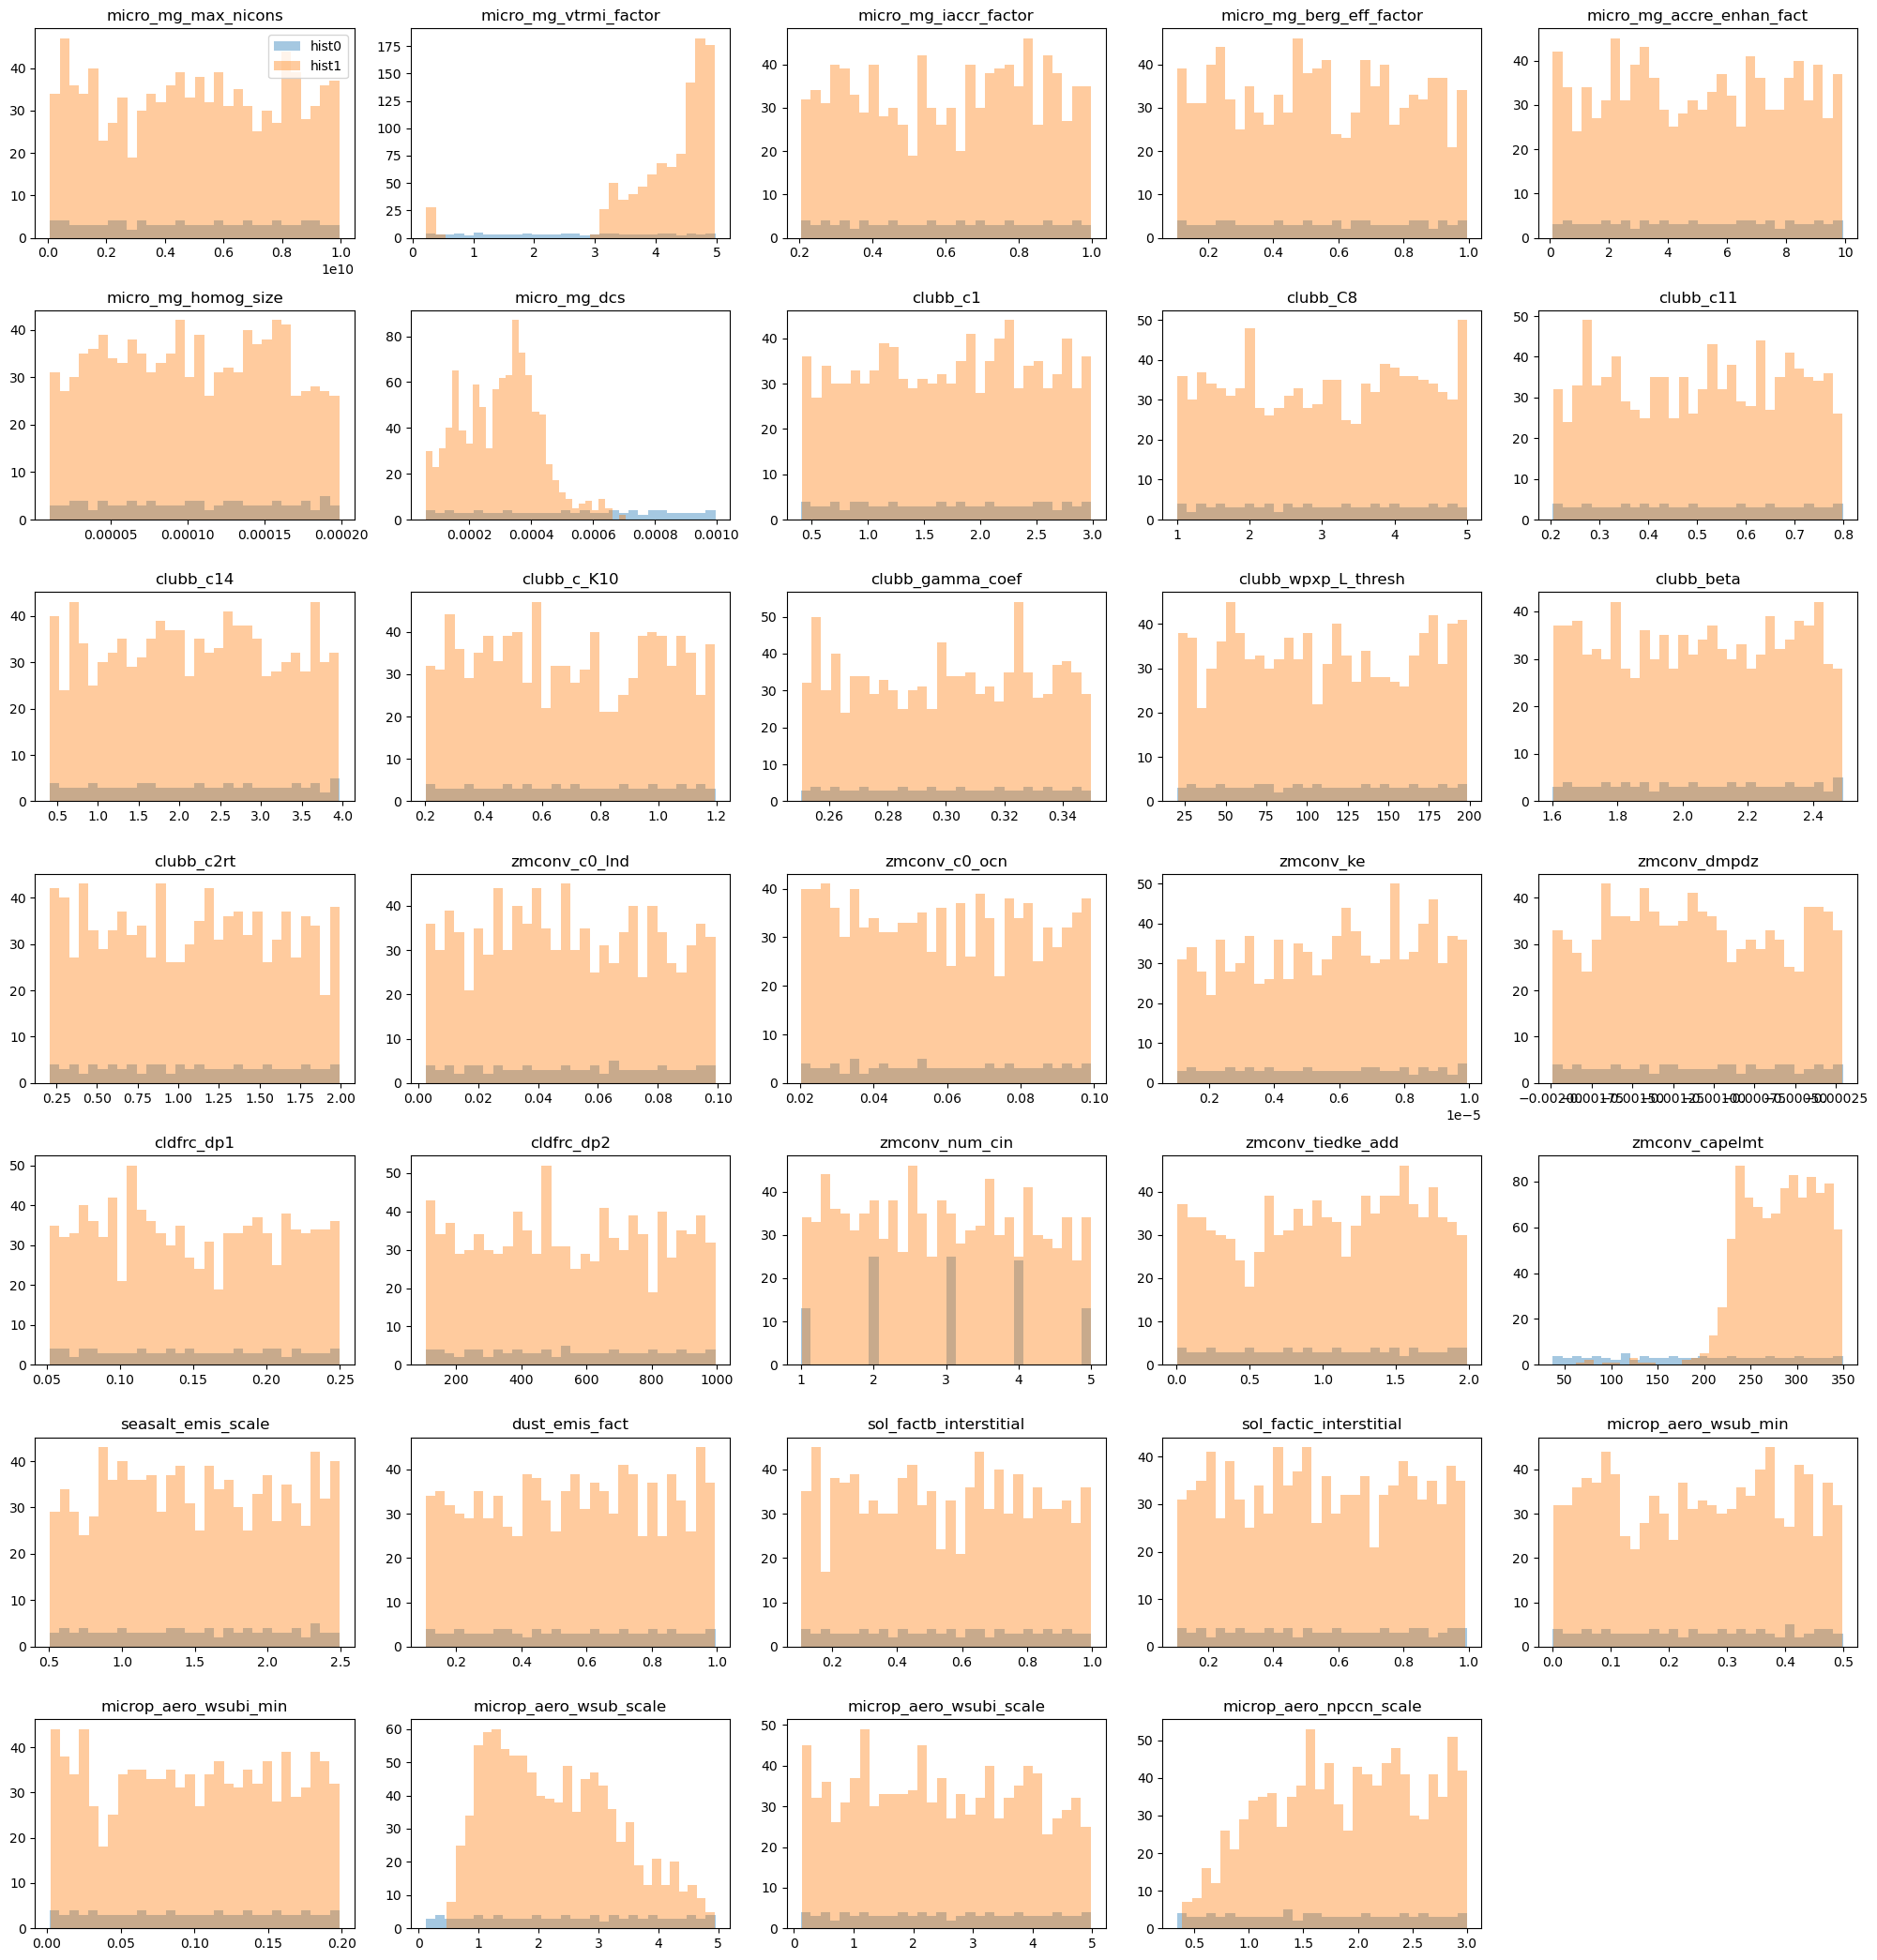

In [66]:
plot_histograms_grid_5([para, test_case.results.realscale_samples])

In [67]:
test_case.save_samples(n = 100)

(1000, 34)
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '